# Experiment: Dataset Sanity Check

Objective:
- Verify that the Kaggle chest X-ray dataset is stored in the expected folder structure.
- Confirm class counts for the provided train/validation/test split.
- Inspect a few sample images and basic image-size statistics before training any model.

Success criteria:
- The dataset path resolves correctly.
- Class counts can be summarized in a small table.
- At least one class-distribution figure is saved for later use in the report.


In [7]:
from __future__ import annotations
import random
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

SEED = 7
random.seed(SEED)

DATASET_ROOT = Path("../data/chest_xray")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT.resolve()}")

DATASET_ROOT.resolve()


WindowsPath('C:/Users/Carolina/OneDrive - 4sb643/Ambiente de Trabalho/UA/CAA/Project/data/chest_xray')

## 1. Verify folder structure and class counts

This cell checks whether the expected split/class folders exist and counts how many images are inside each one.


In [8]:
def list_image_paths(split: str, class_name: str) -> list[Path]:
    folder = DATASET_ROOT / split / class_name
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder: {folder.resolve()}")
    return sorted(path for path in folder.iterdir() if path.is_file())


records = []
for split in SPLITS:
    for class_name in CLASSES:
        image_paths = list_image_paths(split, class_name)
        records.append(
            {
                "split": split,
                "class": class_name,
                "count": len(image_paths),
            }
        )

count_df = pd.DataFrame(records)
count_pivot = count_df.pivot(index="split", columns="class", values="count")

print(count_df.to_string(index=False))
print()
print(count_pivot.to_string())


split     class  count
train    NORMAL   1341
train PNEUMONIA   3875
  val    NORMAL      8
  val PNEUMONIA      8
 test    NORMAL    234
 test PNEUMONIA    390

class  NORMAL  PNEUMONIA
split                   
test      234        390
train    1341       3875
val         8          8


## 2. Plot class distribution

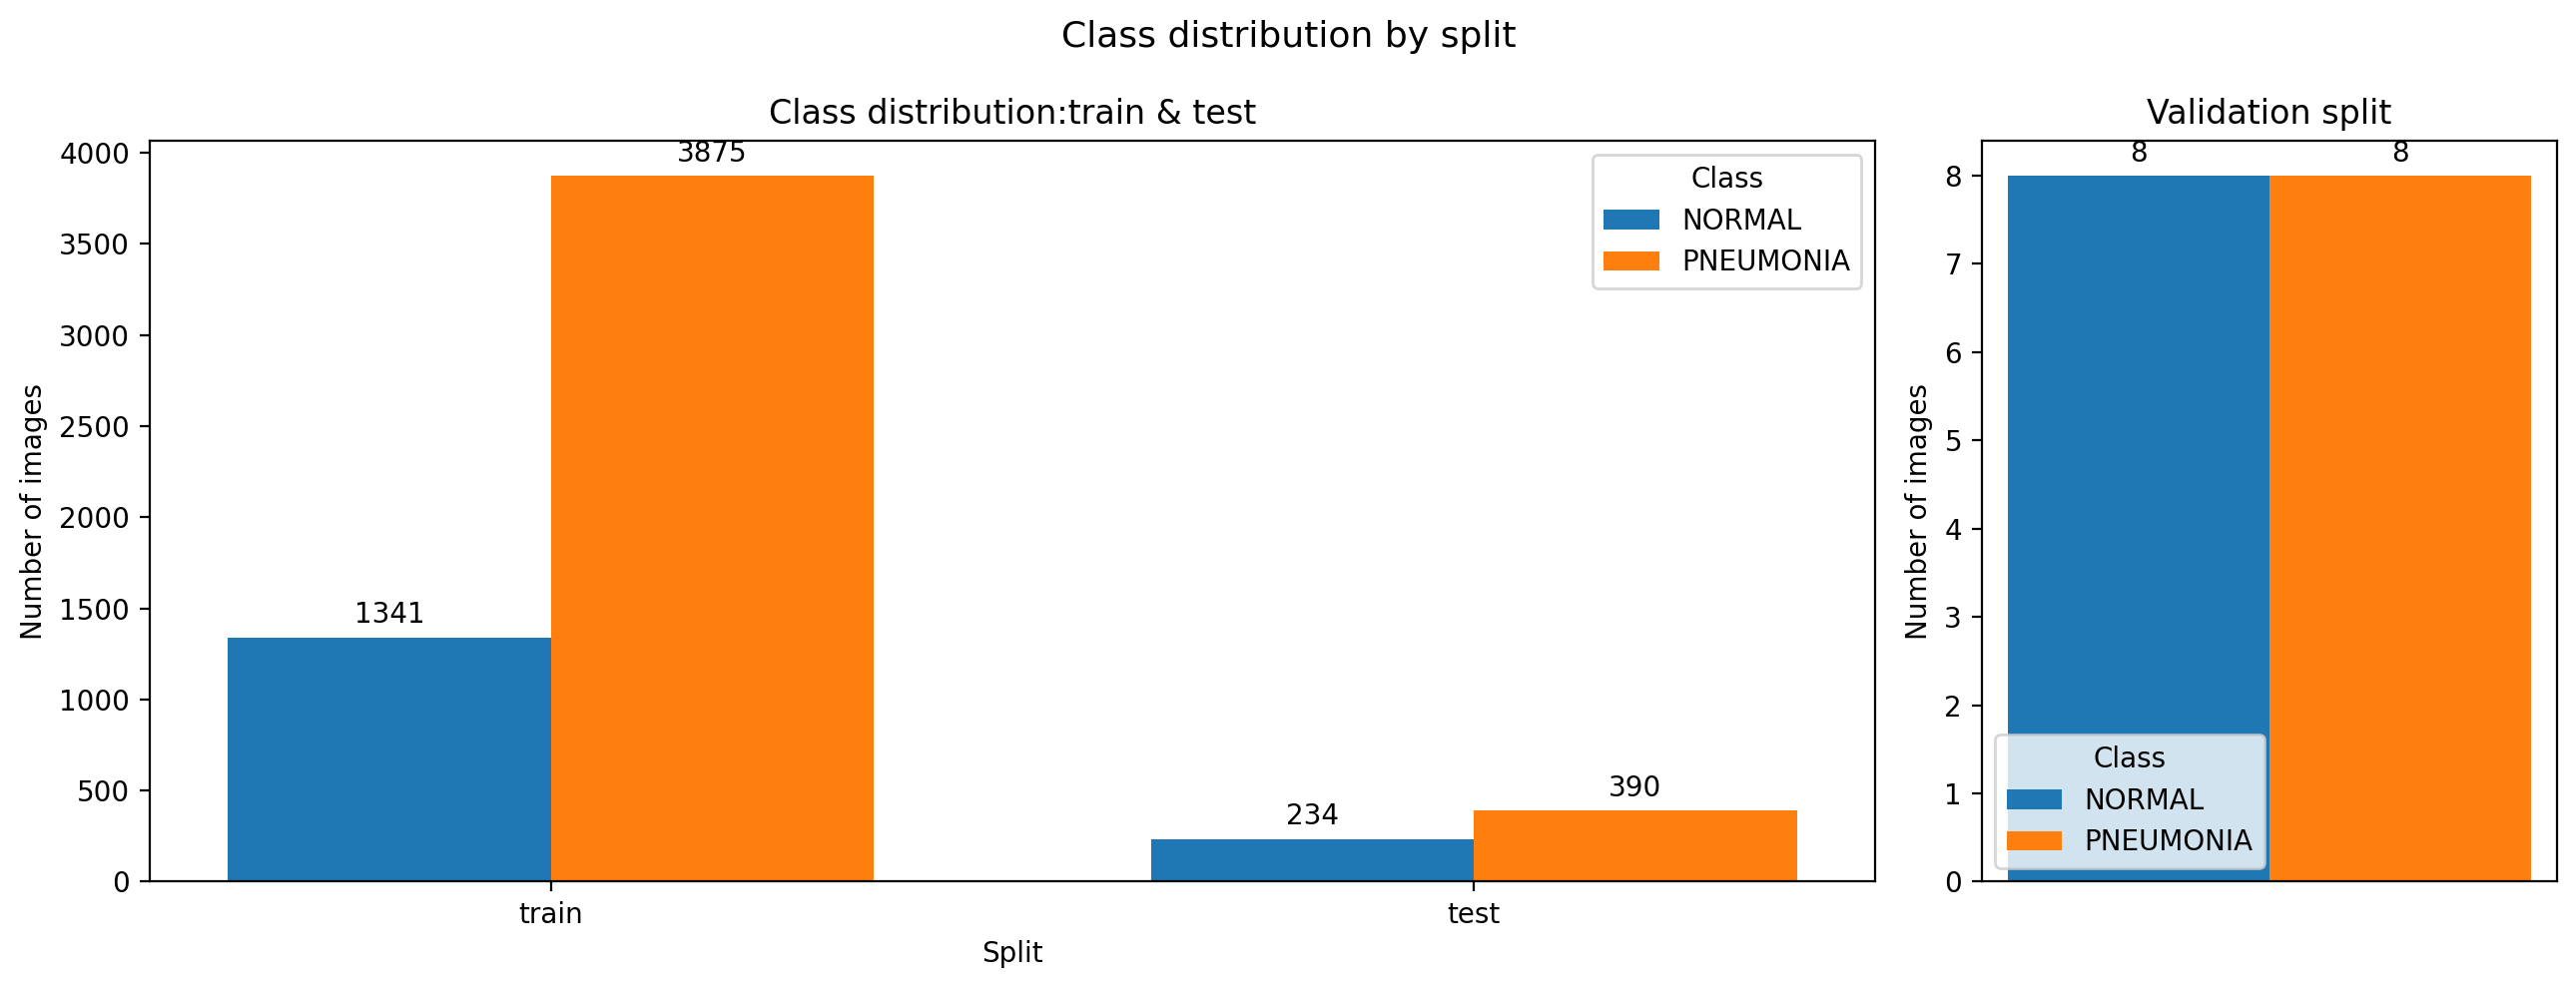

Saved figure to: ..\results\figures\class_distribution.png


In [9]:
import sys
sys.path.insert(0, "../src")
from pneumonia_classifier.visualization.plots import plot_class_distribution
from IPython.display import Image as IPImage, display

counts = {
    split: {cls: int(count_pivot.loc[split, cls]) for cls in CLASSES}
    for split in SPLITS
}
figure_path = plot_class_distribution(counts, output_dir=FIGURES_DIR)
display(IPImage(str(figure_path)))
print(f"Saved figure to: {figure_path}")


## 3. Visualize sample images

We only inspect a few training examples here to make sure the images look sensible and the labels are not obviously broken.


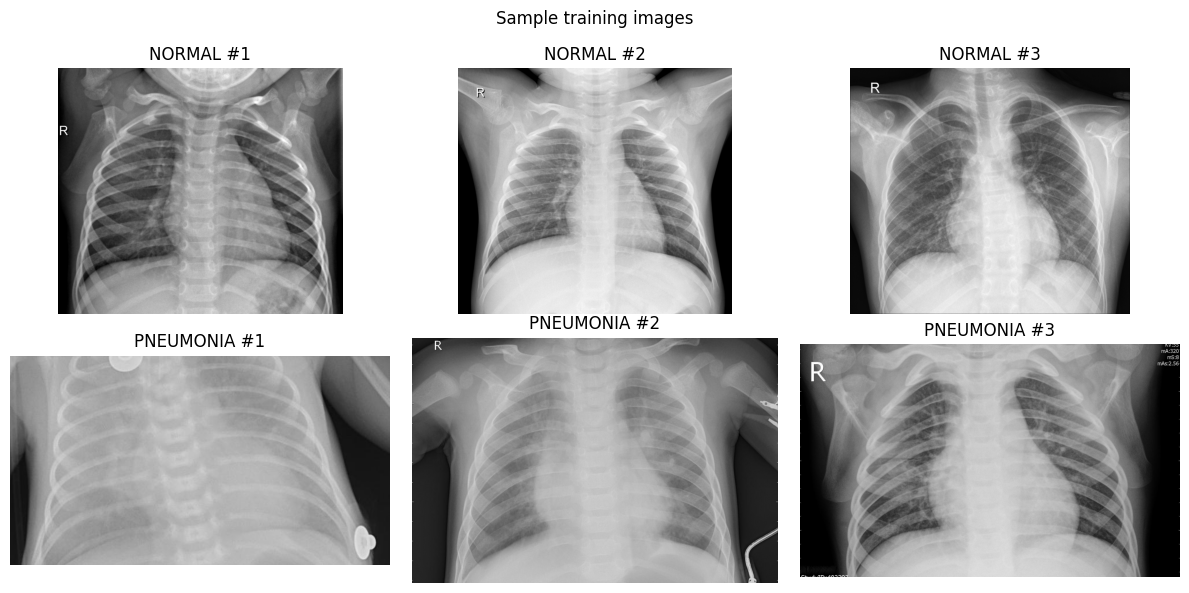

In [10]:
train_samples_per_class = 3
fig, axes = plt.subplots(len(CLASSES), train_samples_per_class, figsize=(12, 6))

for row, class_name in enumerate(CLASSES):
    image_paths = list_image_paths("train", class_name)
    chosen = random.sample(image_paths, k=min(train_samples_per_class, len(image_paths)))

    for col in range(train_samples_per_class):
        ax = axes[row, col]
        ax.axis("off")

        if col < len(chosen):
            with Image.open(chosen[col]) as image:
                ax.imshow(image, cmap="gray")
            ax.set_title(f"{class_name} #{col + 1}")

plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()


## 4. Inspect image sizes

This cell checks whether image resolutions are varied and gives basic statistics before resizing is introduced in the training pipeline.


In [11]:
all_image_paths = []
for split in SPLITS:
    for class_name in CLASSES:
        all_image_paths.extend(list_image_paths(split, class_name))

size_records = []
for path in all_image_paths:
    with Image.open(path) as image:
        width, height = image.size
    size_records.append({"width": width, "height": height})

size_df = pd.DataFrame(size_records)
print(size_df.describe().to_string())

resolution_counts = Counter((item["width"], item["height"]) for item in size_records)
common_resolutions = pd.DataFrame(
    [
        {"resolution": f"{width}x{height}", "count": count}
        for (width, height), count in resolution_counts.most_common(10)
    ]
)
print()
print(common_resolutions.to_string(index=False))


             width       height
count  5856.000000  5856.000000
mean   1327.880806   970.689037
std     363.500922   383.392117
min     384.000000   127.000000
25%    1056.000000   688.000000
50%    1281.000000   888.000000
75%    1560.000000  1187.000000
max    2916.000000  2713.000000

resolution  count
  1072x648      7
  1008x704      7
  1216x872      6
  1080x728      6
   992x592      6
   992x608      6
  1304x968      5
  1088x712      5
  1008x680      5
   976x672      5
